In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import joblib
from sklearn.metrics import roc_curve, auc

# Previsão de Sinistros de Seguro de Carro

## Descrição do Projeto
O presente projeto tem como propósito explorar a aplicação de técnicas de machine learning para prever a probabilidade de um cliente acionar o seguro de seu veículo. Esta análise é relevante para seguradoras, pois permite ajustar os preços das apólices de forma mais precisa e identificar perfis de clientes de maior risco. Utilizando variáveis demográficas, comportamentais e características do veículo, buscamos construir um modelo preditivo eficaz que possa orientar a tomada de decisões estratégicas.


O objetivo principal é desenvolver uma ferramenta que auxilie seguradoras a identificar clientes com maior propensão a sinistros, promovendo tanto a otimização de seus produtos quanto o equilíbrio financeiro e operacional das empresas do setor.

## Justificativa
A previsão precisa de sinistros de seguro é uma ferramenta essencial para o setor de seguros, oferecendo benefícios como:

- **Ajuste de preços de apólices**: Com base no perfil de risco identificado, é possível precificar apólices de forma justa e competitiva.
- **Estratégias de mitigação**: Identificar clientes com maior probabilidade de sinistro permite criar políticas e campanhas específicas para redução do risco.

Por meio deste projeto, esperamos apresentar uma análise robusta e um modelo preditivo confiável, que agregue valor às operações das seguradoras.


# Entendimento dos Dados

## Carregamento dos Dados

Nesta etapa, carregamos o arquivo **Car_Insurance_Claim.csv** utilizando a biblioteca **pandas**. Este processo é fundamental para iniciar a análise exploratória e entender a estrutura do conjunto de dados. Após o carregamento, exibimos as 5 primeiras linhas para verificar os valores e colunas disponíveis.

In [61]:
# Carregando o arquivo Car_Insurance_Claim.csv
caminho_arquivo = 'Car_Insurance_Claim.csv'
dados = pd.read_csv(caminho_arquivo)

# Exibindo as 5 primeiras linhas do dataset
dados_head = dados.head()
dados_head

,ID,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


# Descrição das Variáveis

Nesta etapa, listamos todas as colunas do dataset com breves descrições para facilitar o entendimento. Além disso, classificamos as variáveis em três categorias: demográficas, comportamentais e relacionadas ao veículo, para estruturar melhor a análise.

## Colunas e suas descrições:

| **Coluna**             | **Descrição**                                                                 |
|-------------------------|-------------------------------------------------------------------------------|
| **ID**                 | Identificador único do cliente.                                              |
| **AGE**                | Faixa etária do cliente.                                                     |
| **GENDER**             | Gênero do cliente.                                                           |
| **DRIVING_EXPERIENCE** | Tempo de experiência do cliente como motorista.                              |
| **EDUCATION**          | Nível educacional do cliente.                                                |
| **INCOME**             | Faixa de renda do cliente.                                                   |
| **CREDIT_SCORE**       | Pontuação de crédito do cliente.                                             |
| **VEHICLE_OWNERSHIP**  | Indica se o cliente é proprietário do veículo.                               |
| **VEHICLE_YEAR**       | Ano de fabricação do veículo.                                                |
| **MARRIED**            | Indica se o cliente é casado.                                                |
| **CHILDREN**           | Número de filhos do cliente.                                                 |
| **POSTAL_CODE**        | Código postal de residência do cliente.                                      |
| **ANNUAL_MILEAGE**     | Quilometragem anual do veículo.                                              |
| **VEHICLE_TYPE**       | Tipo de veículo (sedan, SUV, etc.).                                          |
| **SPEEDING_VIOLATIONS**| Número de infrações por excesso de velocidade.                               |
| **DUIS**               | Número de vezes que o cliente foi flagrado dirigindo sob influência.         |
| **PAST_ACCIDENTS**     | Número de acidentes prévios do cliente.                                      |
| **OUTCOME**            | Variável alvo, indicando se o seguro foi acionado (1.0) ou não (0.0).        |

## Classificação das variáveis:
- **Demográficas**: AGE, GENDER, EDUCATION, INCOME, MARRIED, CHILDREN, POSTAL_CODE
- **Comportamentais**: DRIVING_EXPERIENCE, CREDIT_SCORE, SPEEDING_VIOLATIONS, DUIS, PAST_ACCIDENTS
- **Relacionadas ao veículo**: VEHICLE_OWNERSHIP, VEHICLE_YEAR, ANNUAL_MILEAGE, VEHICLE_TYPE

## Verificação dos Tipos de Dados
Nesta etapa, verificamos os tipos de dados das colunas no dataset para identificar se há inconsistências ou se algum tipo de conversão é necessário para o trabalho com os dados. Isso é essencial para evitar erros nas próximas etapas, como análise exploratória e modelagem.

In [62]:
# Verificando os tipos de dados das colunas do dataset
tipos_de_dados = dados.dtypes
tipos_de_dados

ID                       int64
AGE                     object
GENDER                  object
DRIVING_EXPERIENCE      object
EDUCATION               object
INCOME                  object
CREDIT_SCORE           float64
VEHICLE_OWNERSHIP      float64
VEHICLE_YEAR            object
MARRIED                float64
CHILDREN               float64
POSTAL_CODE              int64
ANNUAL_MILEAGE         float64
VEHICLE_TYPE            object
SPEEDING_VIOLATIONS      int64
DUIS                     int64
PAST_ACCIDENTS           int64
OUTCOME                float64
dtype: object

Variáveis como AGE, VEHICLE_YEAR, e outras categóricas (GENDER, etc.) estão no formato object. Vamos convertê-las para um formato adequado (como categórico) para melhor análise.

In [63]:
# Ajustando os tipos de dados das variáveis

# Convertendo colunas categóricas que estão como object para o tipo category
colunas_categoricas = ['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 
                       'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']
for coluna in colunas_categoricas:
    dados[coluna] = dados[coluna].astype('category')

# Confirmando as alterações nos tipos de dados
dados.dtypes

ID                        int64
AGE                    category
GENDER                 category
DRIVING_EXPERIENCE     category
EDUCATION              category
INCOME                 category
CREDIT_SCORE            float64
VEHICLE_OWNERSHIP       float64
VEHICLE_YEAR           category
MARRIED                 float64
CHILDREN                float64
POSTAL_CODE               int64
ANNUAL_MILEAGE          float64
VEHICLE_TYPE           category
SPEEDING_VIOLATIONS       int64
DUIS                      int64
PAST_ACCIDENTS            int64
OUTCOME                 float64
dtype: object

## Identificação e Tratamento de Valores Ausentes

In [64]:
# Verificando valores ausentes no dataset
valores_ausentes = dados.isnull().sum()

# Exibindo as colunas com valores ausentes
valores_ausentes[valores_ausentes > 0]

CREDIT_SCORE      982
ANNUAL_MILEAGE    957
dtype: int64

Identificamos as colunas que possuem valores ausentes no dataset. Estes valores podem impactar a análise e modelagem, sendo necessário tratá-los de maneira apropriada.

Estratégia de tratamento:

- CREDIT_SCORE: Por ser uma variável numérica contínua, vamos preencher os valores ausentes com a mediana para evitar distorções causadas por outliers.
- ANNUAL_MILEAGE: Também sendo uma variável numérica contínua, utilizaremos a mediana para preenchimento.

In [65]:
# Preenchendo valores ausentes com a mediana
dados['CREDIT_SCORE'].fillna(dados['CREDIT_SCORE'].median(), inplace=True)
dados['ANNUAL_MILEAGE'].fillna(dados['ANNUAL_MILEAGE'].median(), inplace=True)

# Verificando novamente se há valores ausentes
dados.isnull().sum()

ID                     0
AGE                    0
GENDER                 0
DRIVING_EXPERIENCE     0
EDUCATION              0
INCOME                 0
CREDIT_SCORE           0
VEHICLE_OWNERSHIP      0
VEHICLE_YEAR           0
MARRIED                0
CHILDREN               0
POSTAL_CODE            0
ANNUAL_MILEAGE         0
VEHICLE_TYPE           0
SPEEDING_VIOLATIONS    0
DUIS                   0
PAST_ACCIDENTS         0
OUTCOME                0
dtype: int64

## Analise distribuições de variáveis contínuas e categóricas.

Nesta etapa, analisamos as distribuições das variáveis contínuas e categóricas para identificar padrões ou anomalias nos dados.

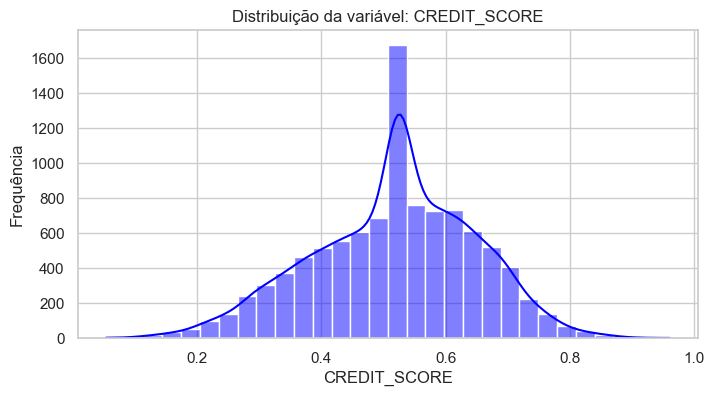

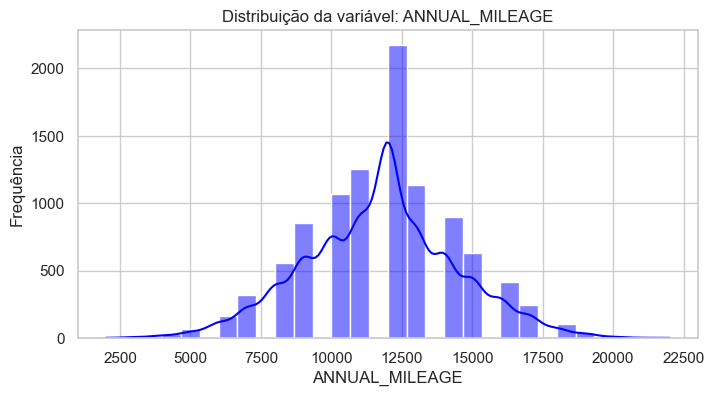

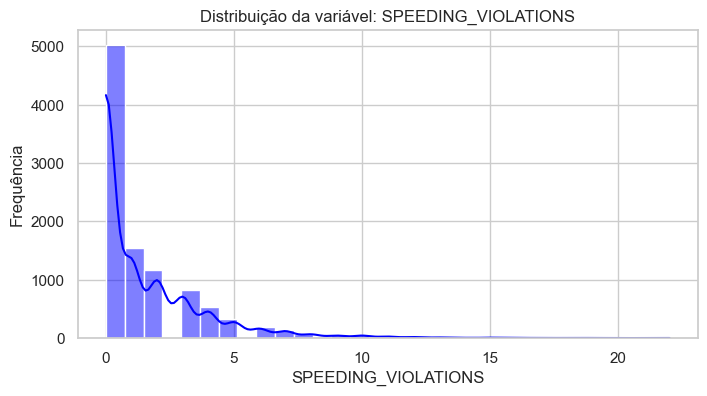

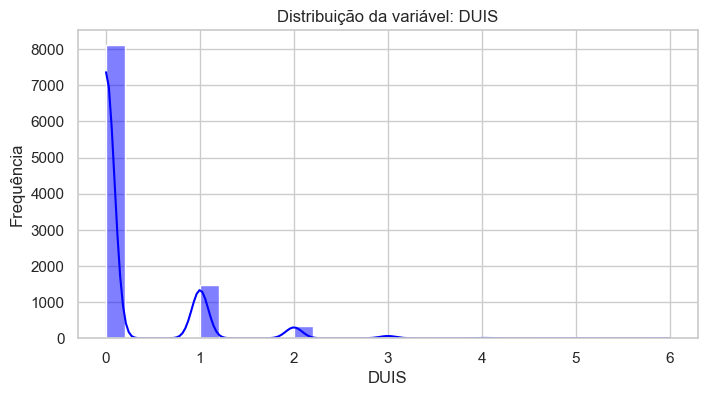

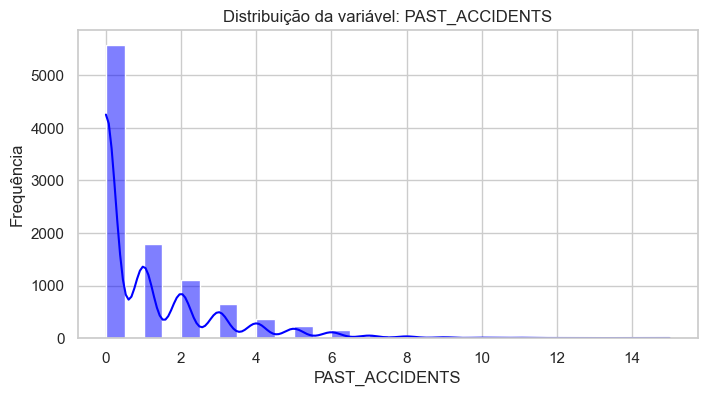

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


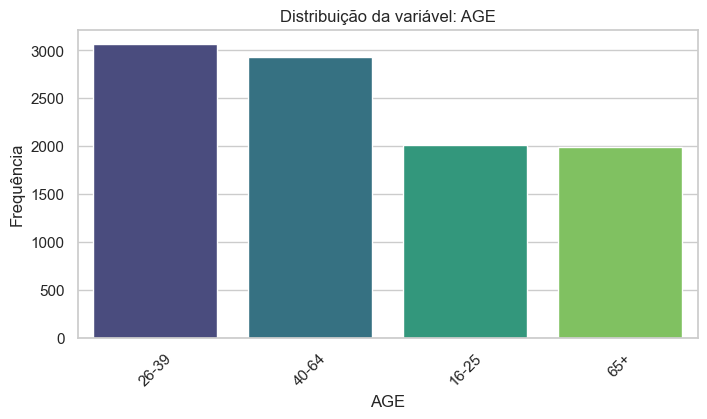

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


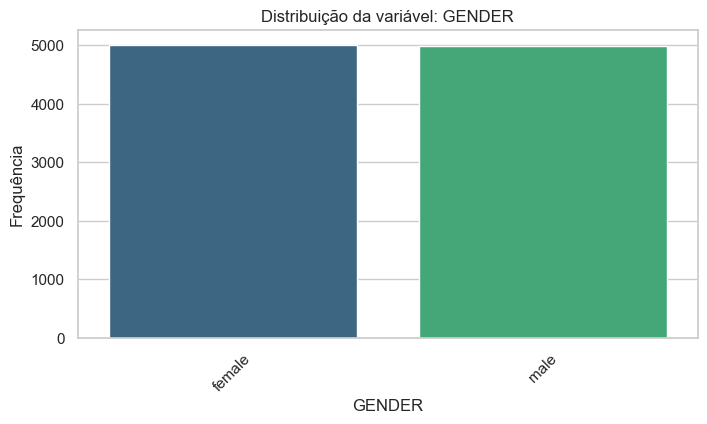

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


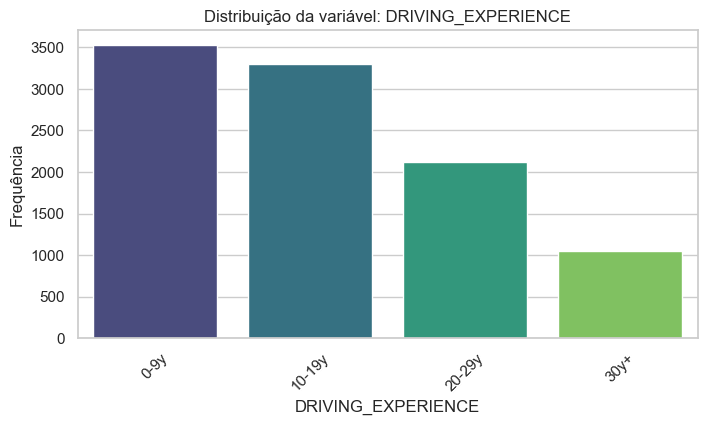

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


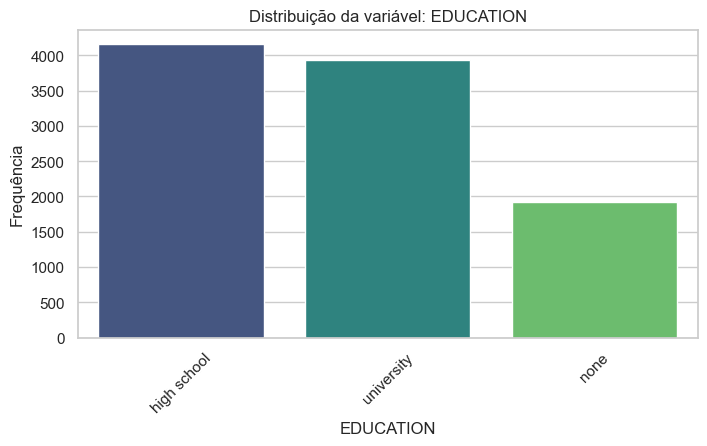

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


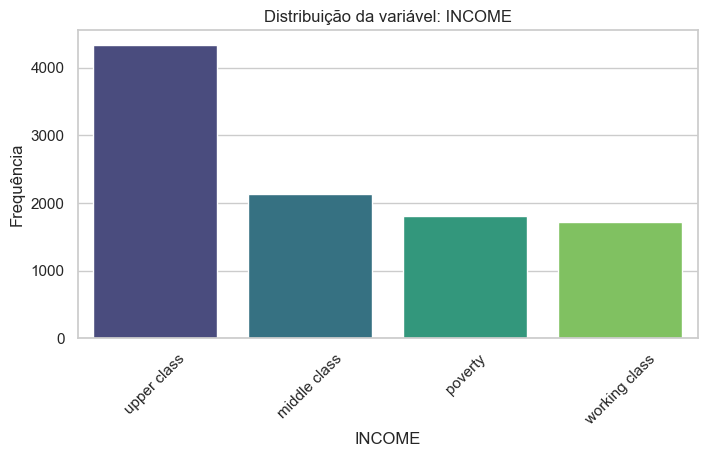

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


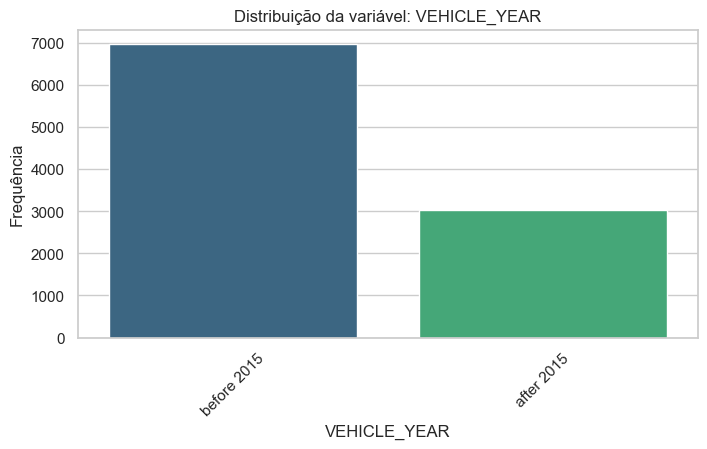

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\2077750578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)


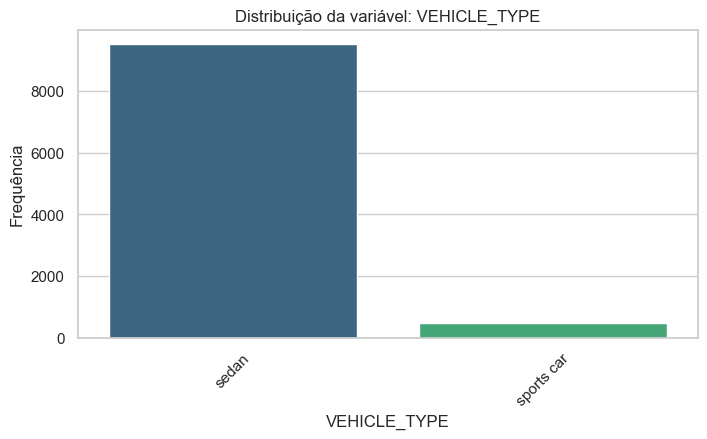

In [67]:
# Configuração de estilo para os gráficos
sns.set(style="whitegrid")

# Variáveis contínuas
variaveis_continuas = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']

# Analisando distribuições das variáveis contínuas
for coluna in variaveis_continuas:
    plt.figure(figsize=(8, 4))
    sns.histplot(dados[coluna], kde=True, bins=30, color="blue")
    plt.title(f'Distribuição da variável: {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')
    plt.show()

# Variáveis categóricas
variaveis_categoricas = ['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']

# Analisando distribuições das variáveis categóricas
for coluna in variaveis_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=dados, x=coluna, palette="viridis", order=dados[coluna].value_counts().index)
    plt.title(f'Distribuição da variável: {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')
    plt.xticks(rotation=45)
    plt.show()


Variáveis contínuas com alta assimetria (como SPEEDING_VIOLATIONS e PAST_ACCIDENTS) podem exigir transformações para melhor adequação aos modelos.

In [70]:
# Função para visualizar as distribuições após transformações
def plot_transformations(data, column, transformations, title_suffix):
    plt.figure(figsize=(16, 8))
    for i, (name, transformed_data) in enumerate(transformations.items(), start=1):
        plt.subplot(1, len(transformations), i)
        sns.histplot(transformed_data, kde=True, bins=30, color="blue")
        plt.title(f'{column} - {name} {title_suffix}')
        plt.xlabel(column)
        plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

# Variáveis a serem transformadas
variaveis = ['SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS']

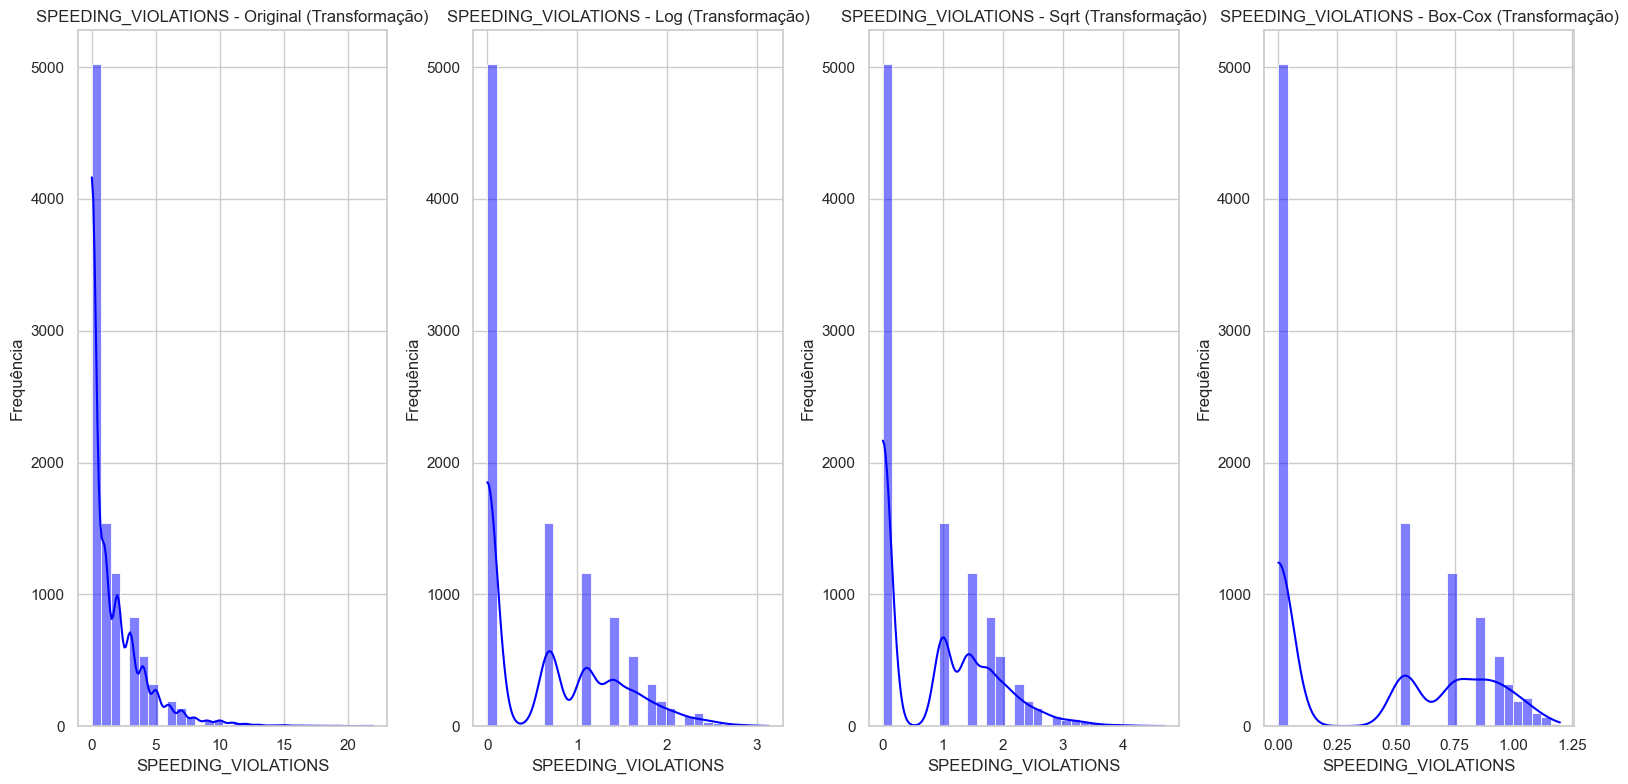

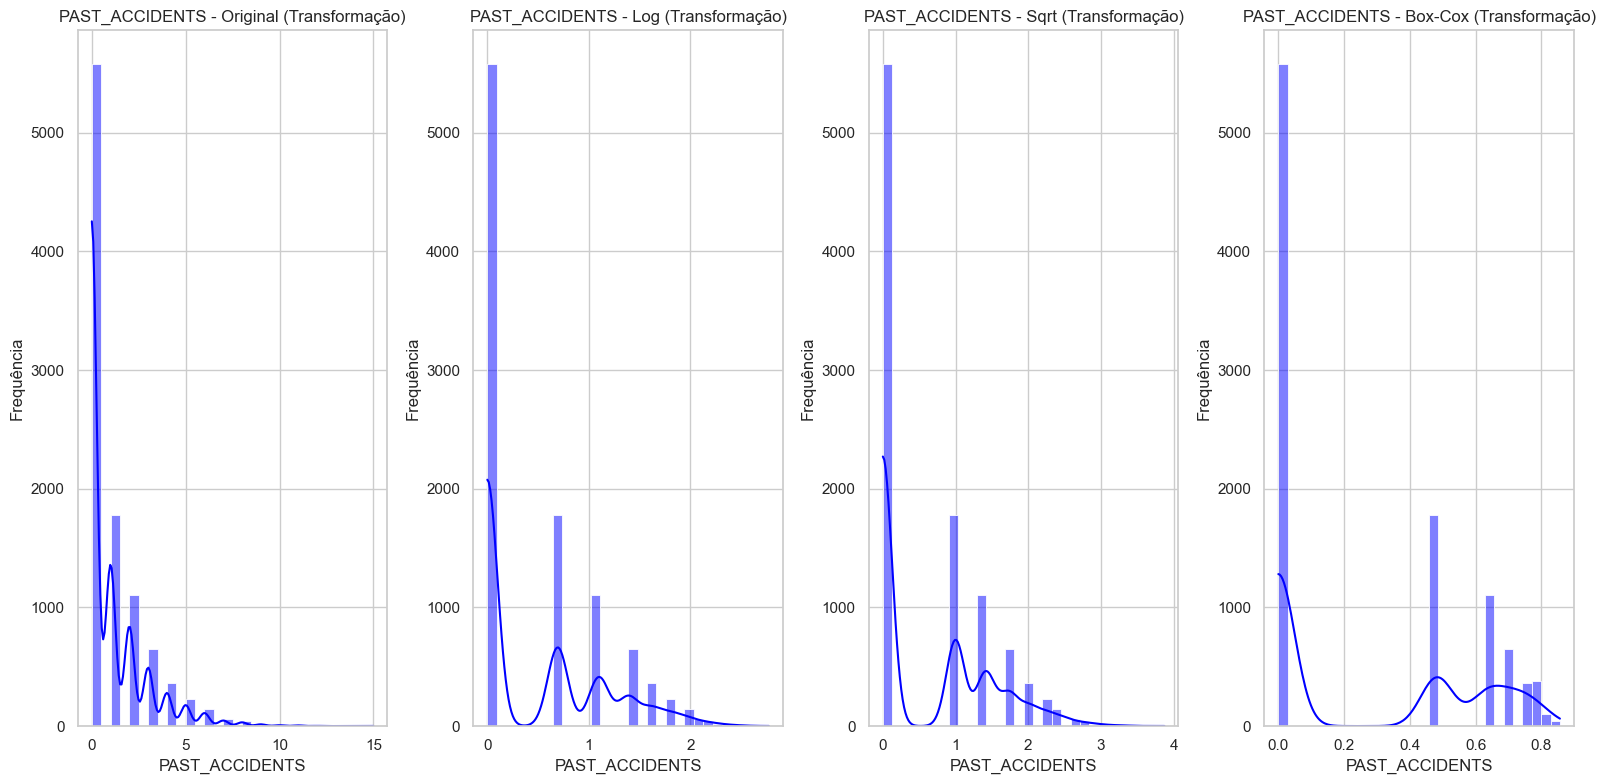

In [71]:
# Aplicando transformações e visualizando resultados
for var in variaveis:
    # Original
    original = dados[var]
    
    # Logarítmica
    log_transform = np.log1p(original)
    
    # Raiz quadrada
    sqrt_transform = np.sqrt(original)
    
    # Box-Cox (adicionando 1 para lidar com zeros)
    boxcox_transform, _ = boxcox(original + 1)
    
    # Coletando transformações
    transformations = {
        "Original": original,
        "Log": log_transform,
        "Sqrt": sqrt_transform,
        "Box-Cox": boxcox_transform
    }
    
    # Visualizando transformações
    plot_transformations(dados, var, transformations, "(Transformação)")

## Conclusão:
- Para ambas as variáveis, a transformação Box-Cox é a mais adequada para reduzir a assimetria e aproximar as distribuições a uma forma mais simétrica.

In [72]:
# Aplicando a transformação Box-Cox nas variáveis
for var in ['SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS']:
    dados[f'{var}_BOXCOX'], _ = boxcox(dados[var] + 1)  # Adicionando 1 para lidar com zeros

# Verificando as novas colunas adicionadas
dados[[f'SPEEDING_VIOLATIONS_BOXCOX', f'PAST_ACCIDENTS_BOXCOX']].head()

,SPEEDING_VIOLATIONS_BOXCOX,PAST_ACCIDENTS_BOXCOX
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.746093,0.482866


# Análise Exploratória de Dados (EDA)

## Estatísticas Descritivas

In [73]:
# Calculando estatísticas descritivas para variáveis contínuas e transformadas
variaveis_para_analise = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 
                          'SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS', 
                          'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX']

estatisticas_descritivas = dados[variaveis_para_analise].describe().T
estatisticas_descritivas['mediana'] = dados[variaveis_para_analise].median()

In [74]:
estatisticas_descritivas

,count,mean,std,min,25%,50%,75%,max,mediana
CREDIT_SCORE,10000.0,0.516718,0.130781,0.053358,0.431509,0.525033,0.607607,0.960819,0.525033
ANNUAL_MILEAGE,10000.0,11726.000000,2681.649329,2000.000000,10000.000000,12000.000000,13000.000000,22000.000000,12000.000000
SPEEDING_VIOLATIONS,10000.0,1.482900,2.241966,0.000000,0.000000,0.000000,2.000000,22.000000,0.000000
PAST_ACCIDENTS,10000.0,1.056300,1.652454,0.000000,0.000000,0.000000,2.000000,15.000000,0.000000
SPEEDING_VIOLATIONS_BOXCOX,10000.0,0.384312,0.407736,0.000000,0.000000,0.000000,0.746093,1.198505,0.000000
PAST_ACCIDENTS_BOXCOX,10000.0,0.270000,0.313320,0.000000,0.000000,0.000000,0.633537,0.856460,0.000000


- **Distribuições assimétricas tratadas**: As transformações Box-Cox melhoraram consideravelmente a simetria de SPEEDING_VIOLATIONS e PAST_ACCIDENTS, o que é benéfico para os modelos que assumem normalidade dos dados.
- **Concentração em zero**: Tanto nas variáveis originais quanto nas transformadas, a mediana de 0.0 destaca que a maioria dos clientes possui comportamento seguro (sem infrações ou acidentes), enquanto um pequeno grupo é responsável pela alta variabilidade.
- **Relevância de análise segmentada**: Para ambas as variáveis, pode ser interessante investigar separadamente os motoristas com valores altos, que podem representar perfis de maior risco.

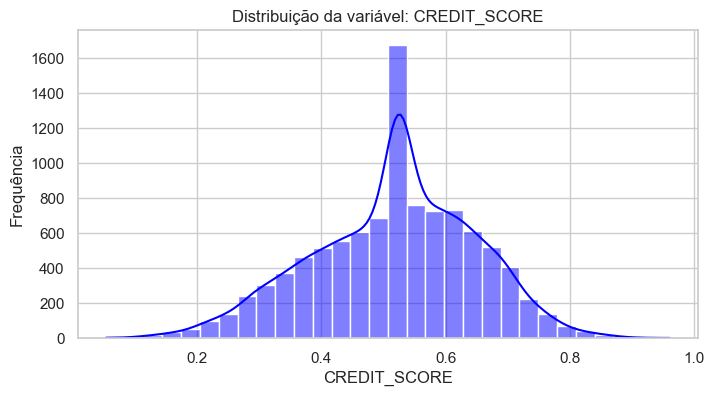

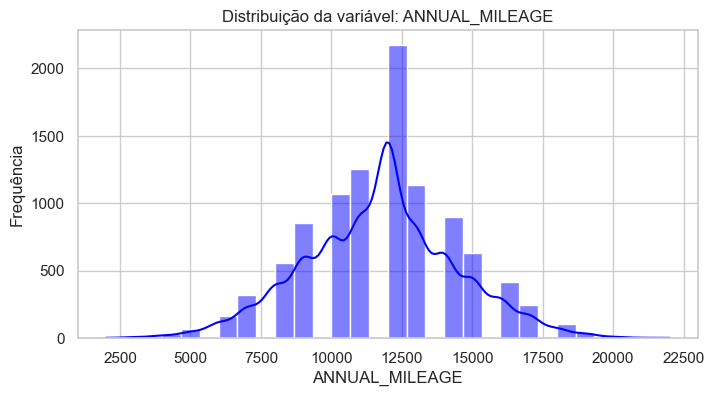

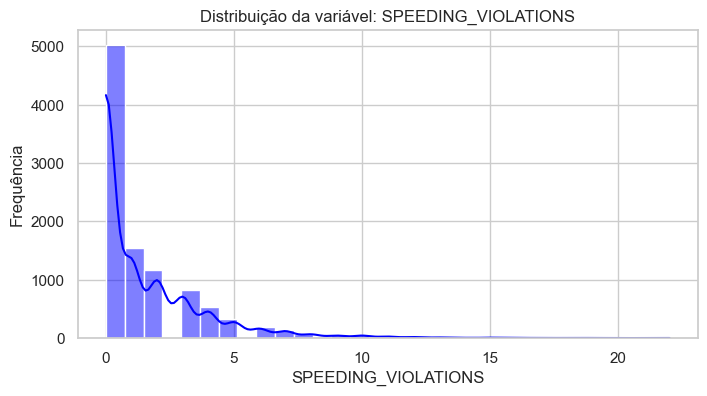

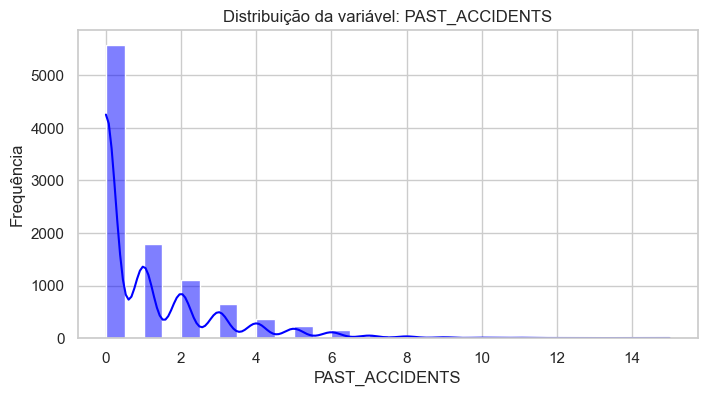

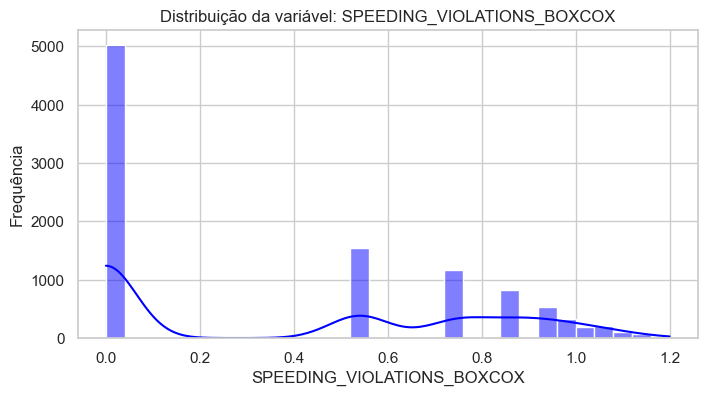

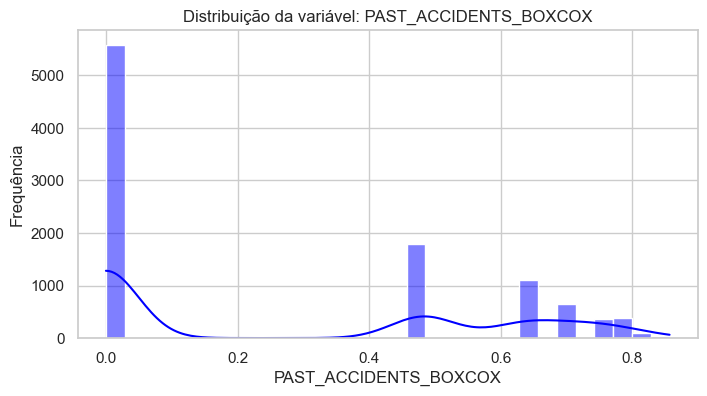

In [75]:
# Plotando as distribuições das variáveis contínuas e transformadas
variaveis_para_distribuicao = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 
                               'SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS', 
                               'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX']

for var in variaveis_para_distribuicao:
    plt.figure(figsize=(8, 4))
    sns.histplot(dados[var], kde=True, bins=30, color="blue")
    plt.title(f'Distribuição da variável: {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.show()

## Análise Univariada:

Nesta etapa, realizamos a análise univariada para visualizar as distribuições das variáveis contínuas do dataset. Utilizamos histogramas para observar o comportamento geral das distribuições e boxplots para identificar possíveis outliers. Este processo ajuda a entender melhor a natureza dos dados e a identificar possíveis ajustes ou características relevantes

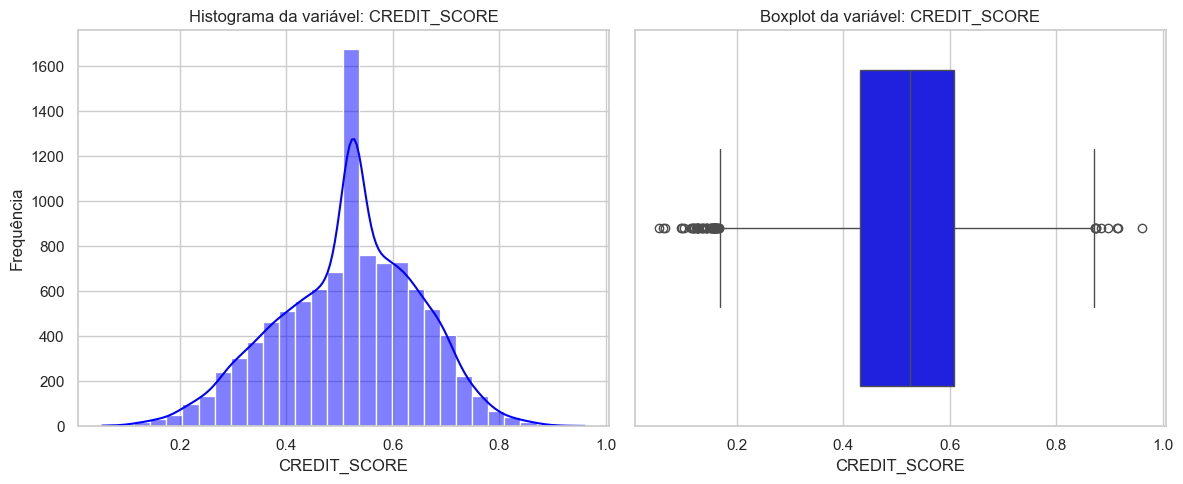

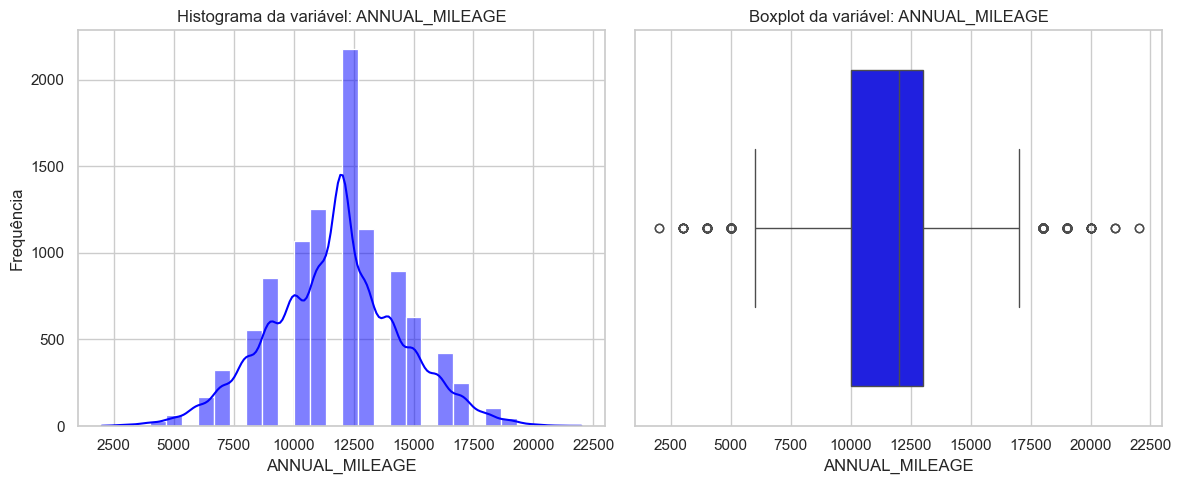

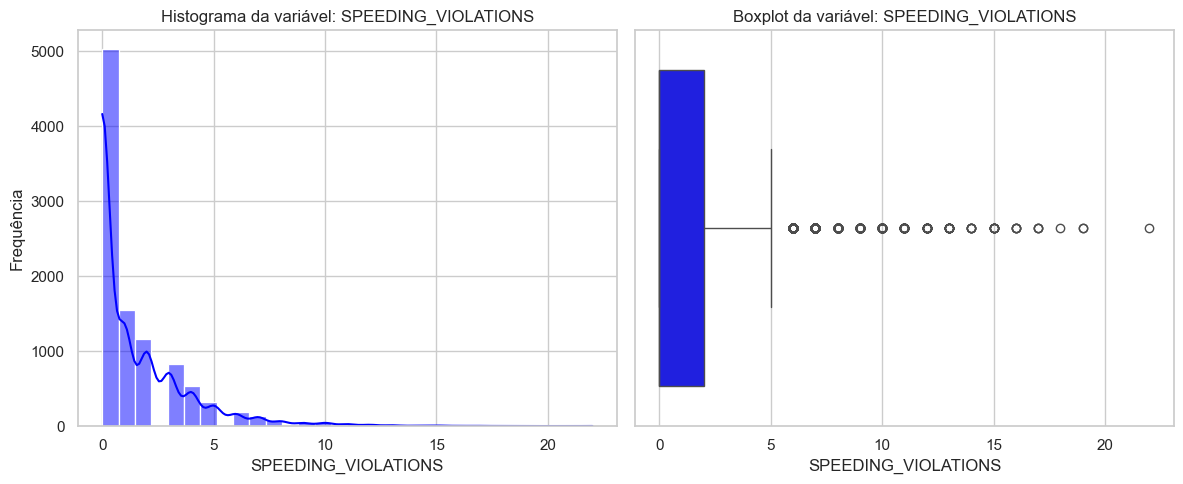

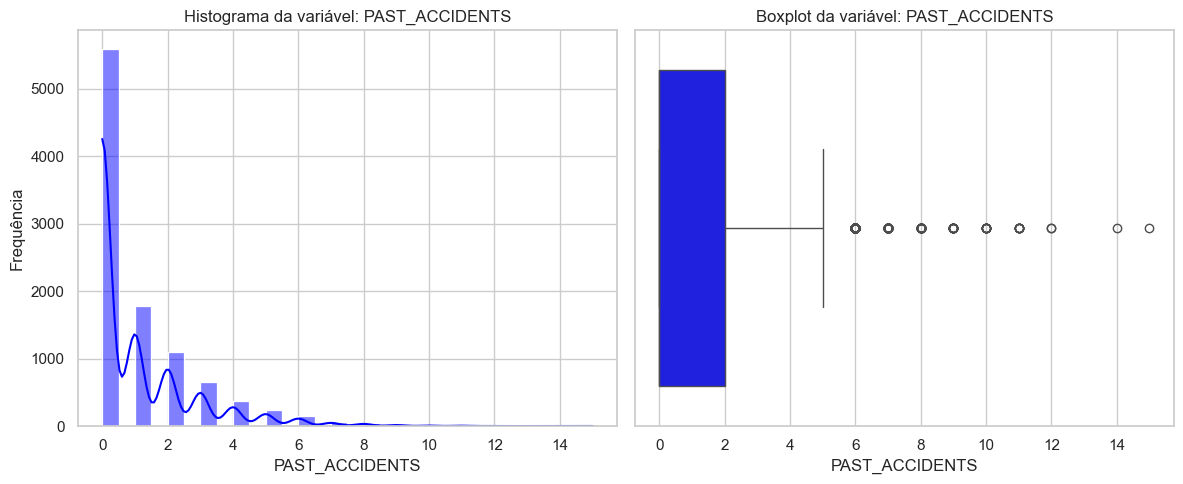

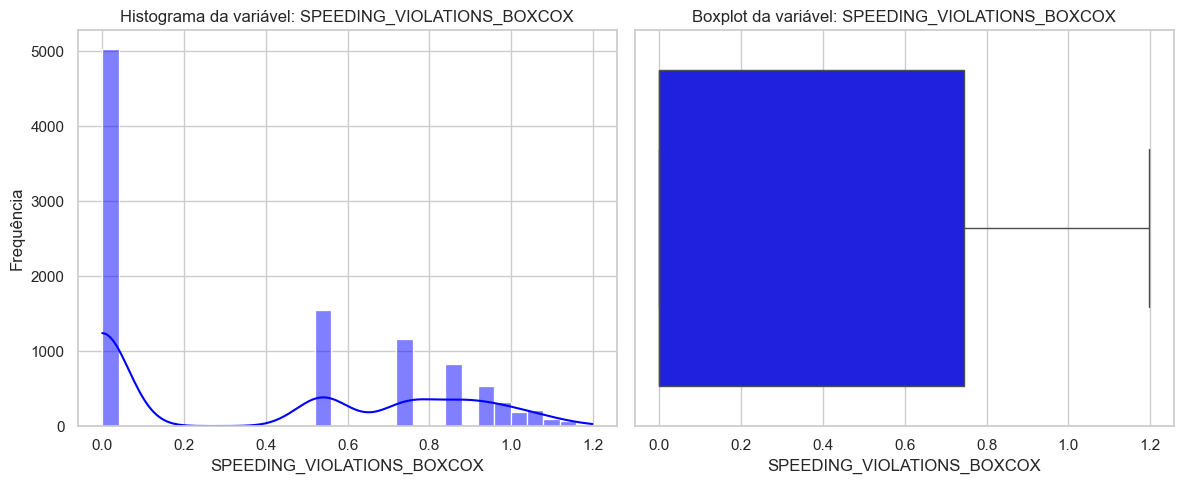

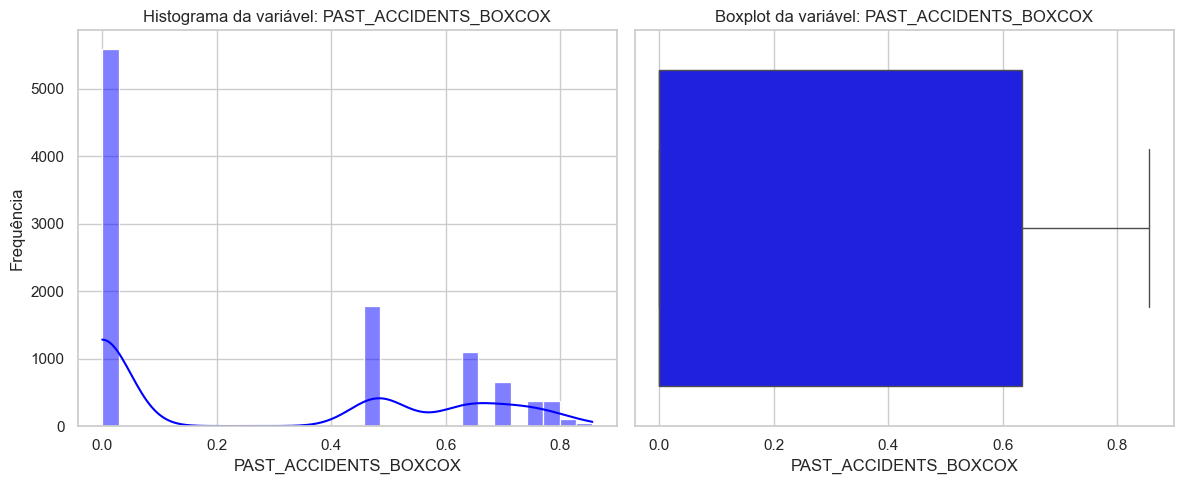

In [76]:
# Análise Univariada: Visualizando distribuições com histogramas e boxplots

# Variáveis contínuas para análise
variaveis_continuas = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 
                       'SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS', 
                       'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX']

for var in variaveis_continuas:
    plt.figure(figsize=(12, 5))
    
    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(dados[var], kde=True, bins=30, color="blue")
    plt.title(f'Histograma da variável: {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=dados[var], color="blue")
    plt.title(f'Boxplot da variável: {var}')
    plt.xlabel(var)
    
    plt.tight_layout()
    plt.show()

## Análise Bivariada

Nesta análise, avaliamos as relações entre as variáveis independentes (contínuas e categóricas) e a variável-alvo OUTCOME, utilizando gráficos de dispersão (scatter plots) e gráficos de barras. Os scatter plots mostram como as variáveis contínuas estão relacionadas com a probabilidade de acionamento do seguro, enquanto os gráficos de barras mostram a média de acionamento do seguro para cada categoria.

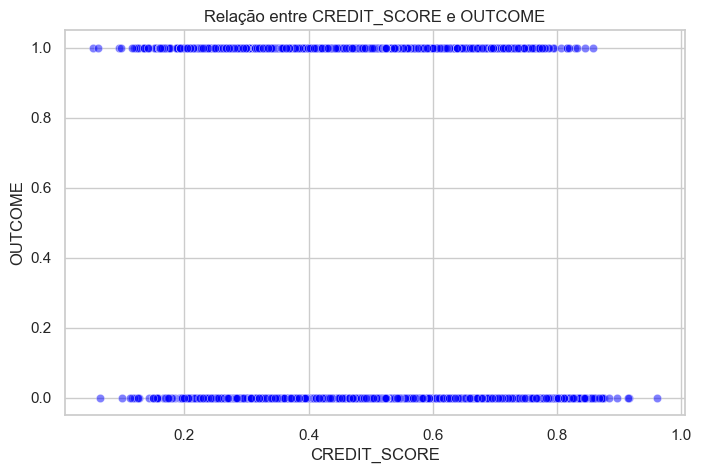

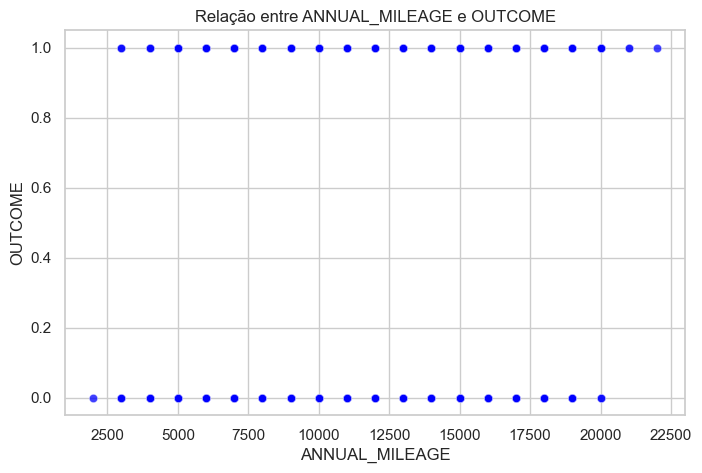

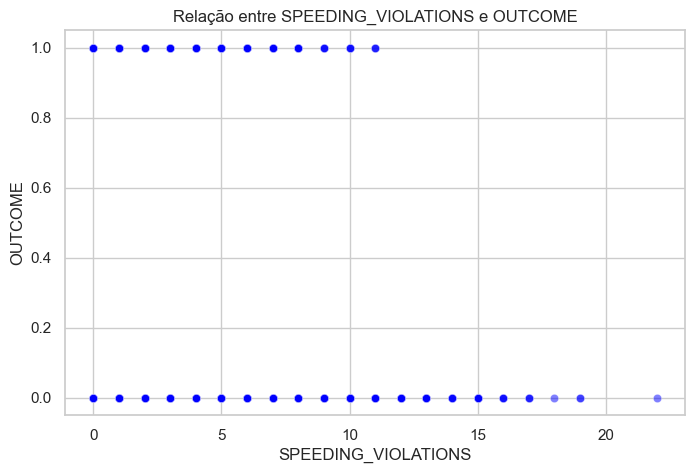

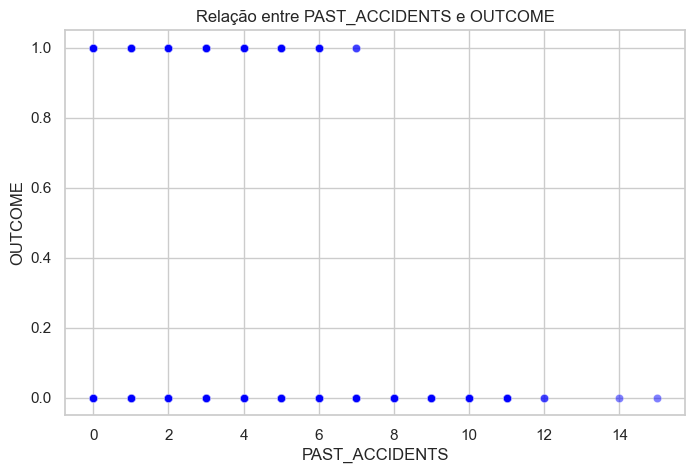

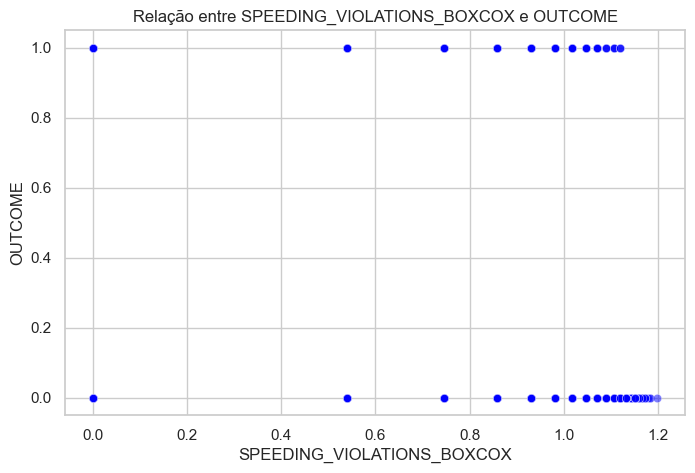

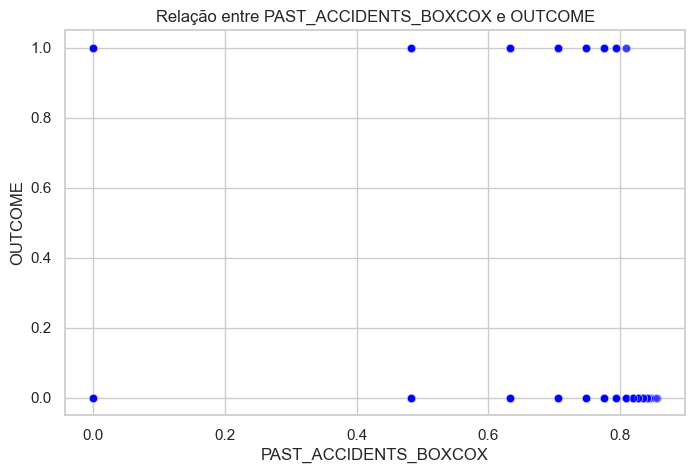

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


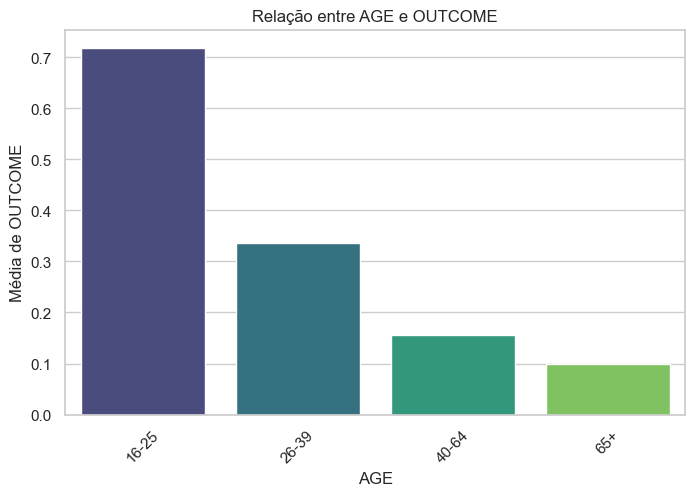

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


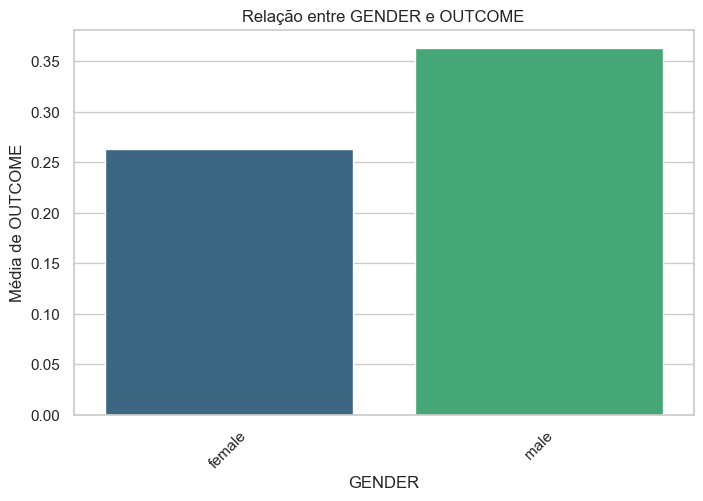

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


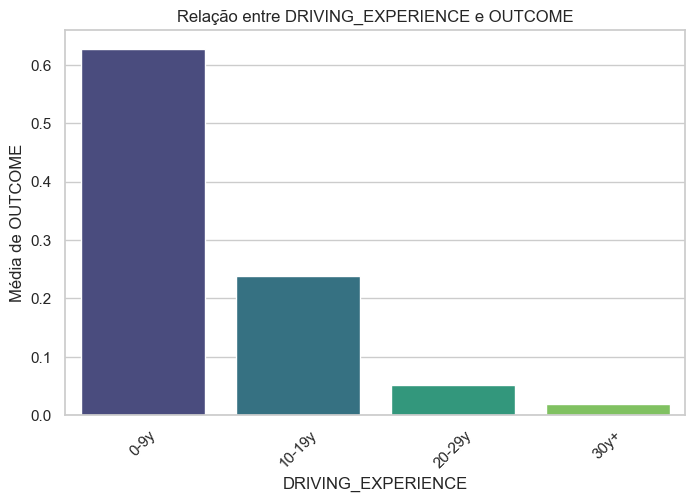

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


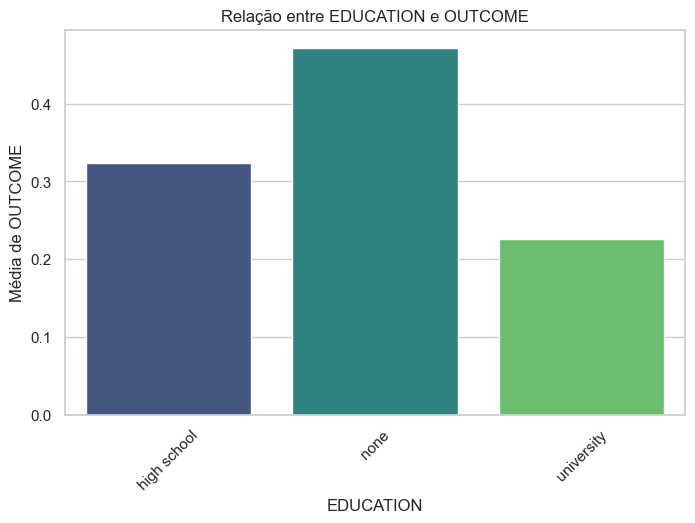

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


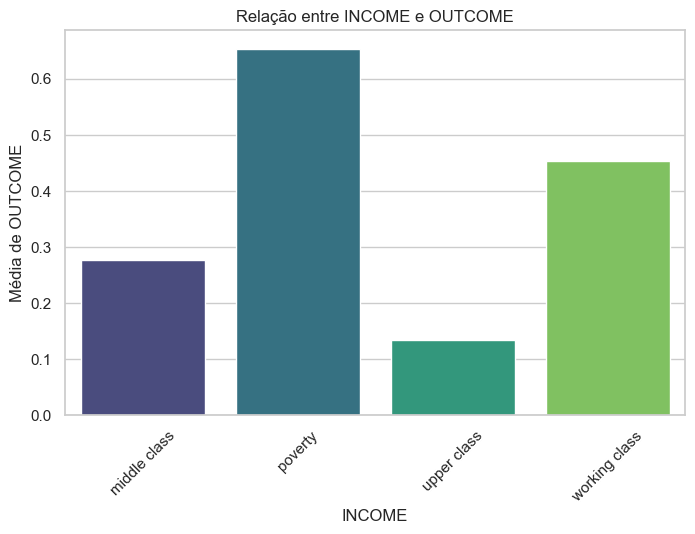

C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
C:\Users\Matheus Cerqueira\AppData\Local\Temp\ipykernel_1388\1238200757.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")


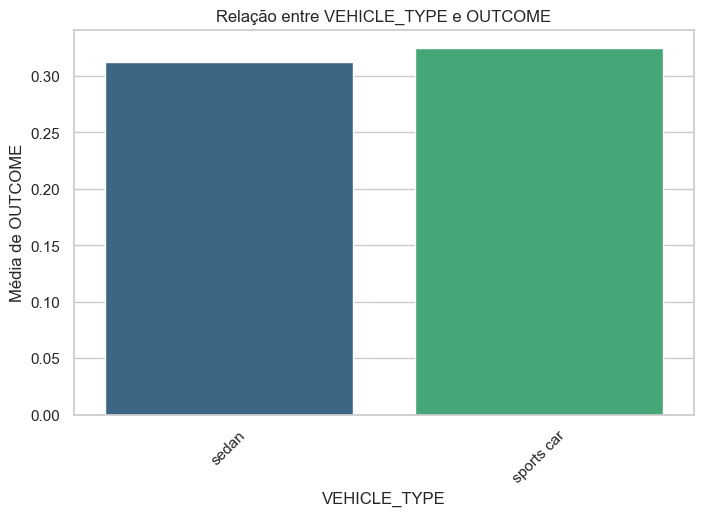

In [77]:
# Análise Bivariada: Relacionando variáveis independentes com a variável-alvo (OUTCOME)

# Variáveis contínuas para análise com scatter plots
variaveis_continuas = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 
                       'SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS', 
                       'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX']

# Scatter plots para variáveis contínuas em relação ao OUTCOME
for var in variaveis_continuas:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=dados, x=var, y='OUTCOME', alpha=0.5, color="blue")
    plt.title(f'Relação entre {var} e OUTCOME')
    plt.xlabel(var)
    plt.ylabel('OUTCOME')
    plt.show()

# Variáveis categóricas para análise com gráficos de barras
variaveis_categoricas = ['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 
                         'EDUCATION', 'INCOME', 'VEHICLE_TYPE']

# Gráficos de barras para variáveis categóricas em relação ao OUTCOME
for var in variaveis_categoricas:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=dados, x=var, y='OUTCOME', ci=None, palette="viridis")
    plt.title(f'Relação entre {var} e OUTCOME')
    plt.xlabel(var)
    plt.ylabel('Média de OUTCOME')
    plt.xticks(rotation=45)
    plt.show()

- As variáveis relacionadas ao comportamento do motorista (ex.: infrações, acidentes) e características demográficas (ex.: idade, experiência ao volante) parecem ser determinantes importantes para prever o acionamento do seguro.
- As diferenças observadas em VEHICLE_TYPE e INCOME destacam a relevância de fatores socioeconômicos e características do veículo na previsão de sinistros.

## Identificação de Correlações

Nesta etapa, geramos uma matriz de correlação para as variáveis numéricas do dataset e utilizamos um mapa de calor para visualizar as relações entre elas. Além disso, identificamos casos de multicolinearidade (correlações fortes acima de 0.8) que podem impactar negativamente a modelagem.

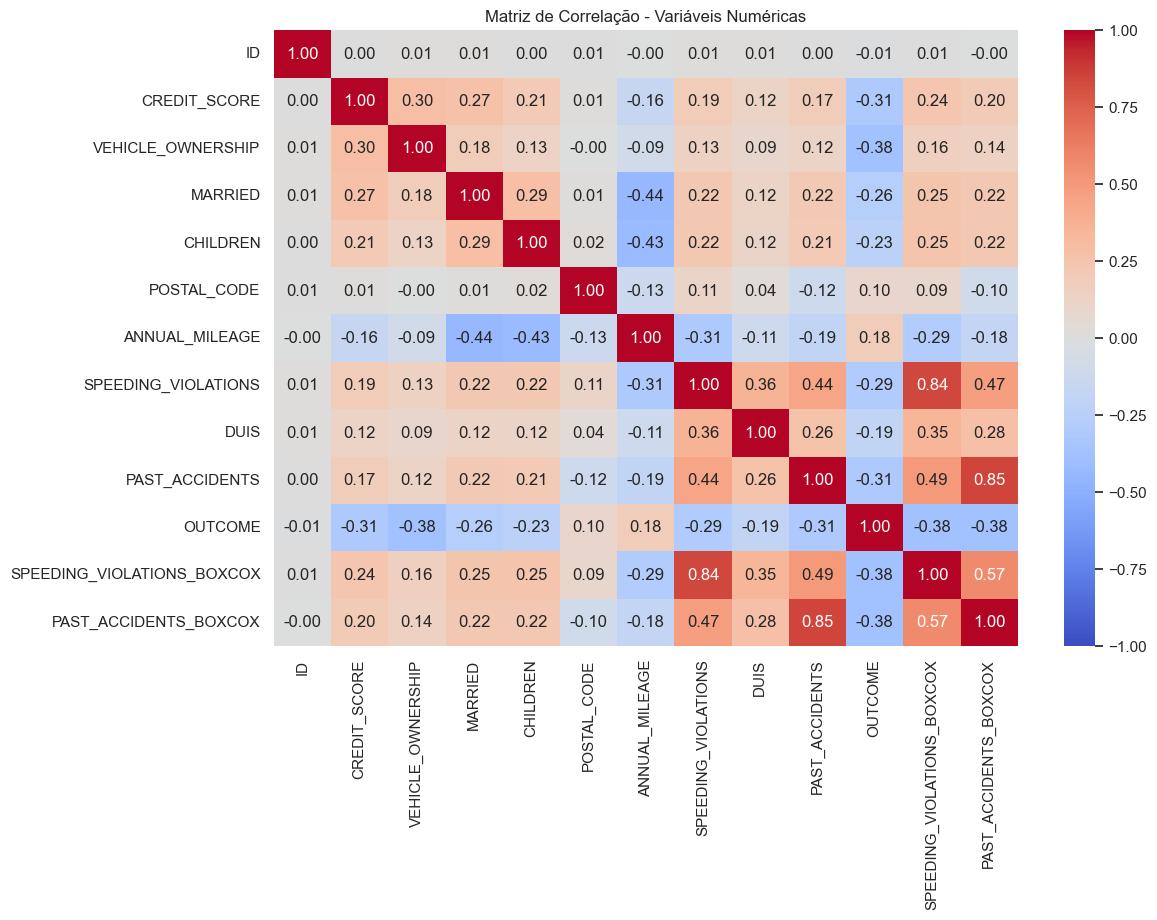

,SPEEDING_VIOLATIONS,PAST_ACCIDENTS,SPEEDING_VIOLATIONS_BOXCOX,PAST_ACCIDENTS_BOXCOX
SPEEDING_VIOLATIONS,NaN,NaN,0.838127,NaN
PAST_ACCIDENTS,NaN,NaN,NaN,0.849541
SPEEDING_VIOLATIONS_BOXCOX,0.838127,NaN,NaN,NaN
PAST_ACCIDENTS_BOXCOX,NaN,0.849541,NaN,NaN


In [79]:
# Selecionando variáveis numéricas para análise de correlação
variaveis_numericas = dados.select_dtypes(include=[np.number])

# Gerando a matriz de correlação
matriz_correlacao = variaveis_numericas.corr()

# Visualizando a matriz de correlação como mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

# Identificando multicolinearidade (valores acima de 0.8)
correlacoes_fortes = matriz_correlacao[(matriz_correlacao > 0.8) & (matriz_correlacao < 1.0)]
correlacoes_fortes.dropna(how='all', inplace=True)
correlacoes_fortes.dropna(axis=1, how='all', inplace=True)

correlacoes_fortes

In [80]:
# Removendo as variáveis originais com multicolinearidade
# Optando pelas variáveis transformadas (Box-Cox)
variaveis_para_remover = ['SPEEDING_VIOLATIONS', 'PAST_ACCIDENTS']
dados.drop(columns=variaveis_para_remover, inplace=True)

# Verificando as colunas restantes no dataset
colunas_ajustadas = dados.columns
colunas_ajustadas

Index(['ID', 'AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR', 'MARRIED',
       'CHILDREN', 'POSTAL_CODE', 'ANNUAL_MILEAGE', 'VEHICLE_TYPE', 'DUIS',
       'OUTCOME', 'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX'],
      dtype='object')

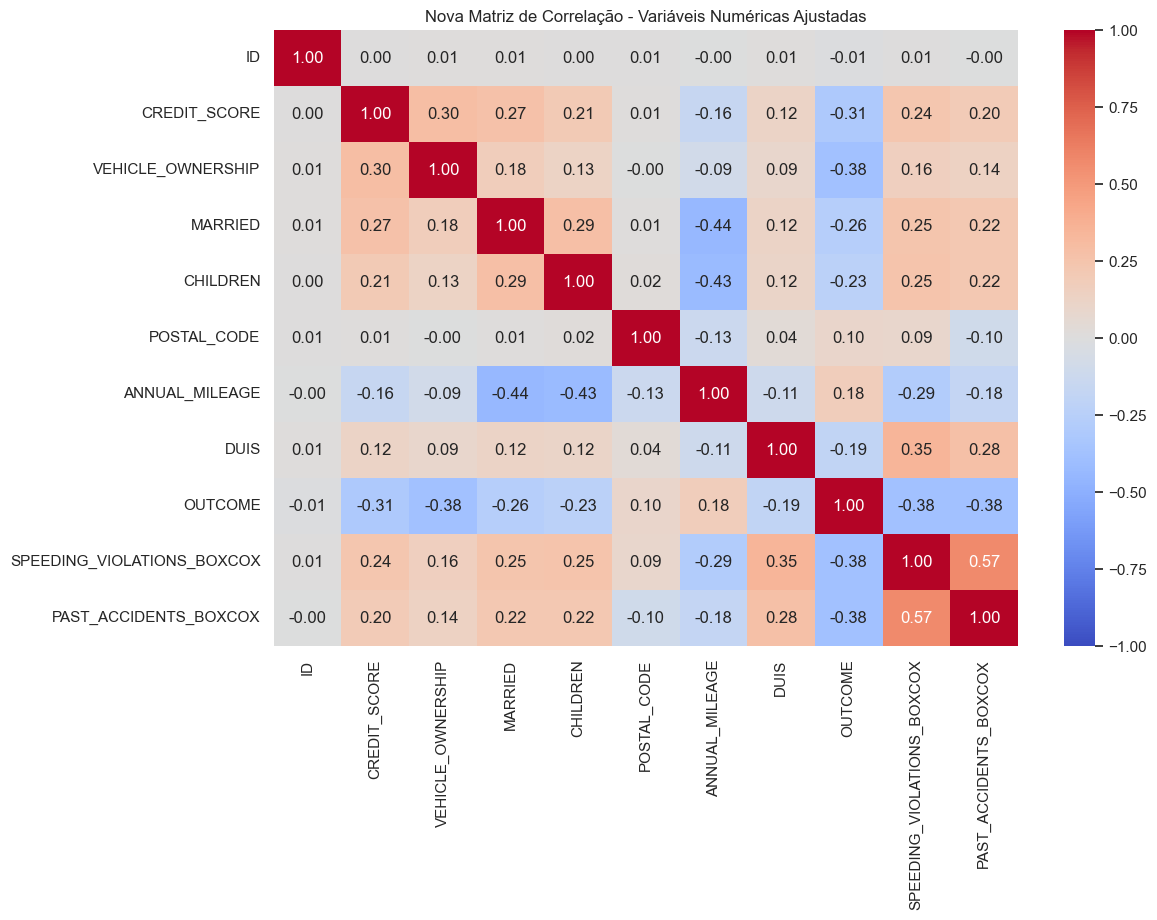

""


In [81]:
# Gerando a nova matriz de correlação após os ajustes
nova_matriz_correlacao = dados.select_dtypes(include=[np.number]).corr()

# Visualizando a nova matriz de correlação como mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(nova_matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Nova Matriz de Correlação - Variáveis Numéricas Ajustadas")
plt.show()

# Identificando multicolinearidade (valores acima de 0.8)
nova_correlacoes_fortes = nova_matriz_correlacao[(nova_matriz_correlacao > 0.8) & (nova_matriz_correlacao < 1.0)]
nova_correlacoes_fortes.dropna(how='all', inplace=True)
nova_correlacoes_fortes.dropna(axis=1, how='all', inplace=True)

nova_correlacoes_fortes

**OUTCOME** continua apresentando correlações mais fortes com variáveis como:
- **CREDIT_SCORE** (-0.31)
- **VEHICLE_OWNERSHIP** (-0.38)
- **SPEEDING_VIOLATIONS_BOXCOX** (0.35)
- **PAST_ACCIDENTS_BOXCOX** (0.57)

**Multicolinearidade**:
- A análise confirma que todas as variáveis independentes são adequadas para modelagem, sem redundância.

# Pré-processamento de Dados

## Codificação de Variáveis Categóricas

As variáveis categóricas foram identificadas e codificadas utilizando a técnica de One-Hot Encoding. Essa abordagem cria novas colunas para cada categoria, representando-as como valores binários (0 ou 1). Para evitar redundância, a primeira categoria de cada variável foi descartada com o parâmetro

In [82]:
# Identificando variáveis categóricas no dataset
variaveis_categoricas = dados.select_dtypes(include=['category', 'object']).columns

# Aplicando One-Hot Encoding às variáveis categóricas
dados_codificados = pd.get_dummies(dados, columns=variaveis_categoricas, drop_first=True)

# Verificando o dataset após a codificação
dados_codificados.head()

,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,DUIS,OUTCOME,SPEEDING_VIOLATIONS_BOXCOX,...,DRIVING_EXPERIENCE_10-19y,DRIVING_EXPERIENCE_20-29y,DRIVING_EXPERIENCE_30y+,EDUCATION_none,EDUCATION_university,INCOME_poverty,INCOME_upper class,INCOME_working class,VEHICLE_YEAR_before 2015,VEHICLE_TYPE_sports car
0,569520,0.629027,1.0,0.0,1.0,10238,12000.0,0,0.0,0.000000,...,False,False,False,False,False,False,True,False,False,False
1,750365,0.357757,0.0,0.0,0.0,10238,16000.0,0,1.0,0.000000,...,False,False,False,True,False,True,False,False,True,False
2,199901,0.493146,1.0,0.0,0.0,10238,11000.0,0,0.0,0.000000,...,False,False,False,False,False,False,False,True,True,False
3,478866,0.206013,1.0,0.0,1.0,32765,11000.0,0,0.0,0.000000,...,False,False,False,False,True,False,False,True,True,False
4,731664,0.388366,1.0,0.0,0.0,32765,12000.0,0,1.0,0.746093,...,True,False,False,True,False,False,False,True,True,False


## Normalização/Escala das Variáveis Contínuas
As variáveis contínuas identificadas foram padronizadas utilizando a técnica de StandardScaler. Esse método transforma os valores para que tenham média 0 e desvio padrão 1, o que melhora a performance de muitos modelos preditivos, especialmente aqueles sensíveis à escala, como regressão logística e SVM.


In [87]:
# Identificando variáveis contínuas para padronização
variaveis_continuas = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 
                       'SPEEDING_VIOLATIONS_BOXCOX', 'PAST_ACCIDENTS_BOXCOX']

# Inicializando o StandardScaler
scaler = StandardScaler()

# Aplicando a padronização
dados_codificados[variaveis_continuas] = scaler.fit_transform(dados_codificados[variaveis_continuas])

# Verificando as variáveis contínuas após a normalização
dados_codificados[variaveis_continuas].head()

,CREDIT_SCORE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS_BOXCOX,PAST_ACCIDENTS_BOXCOX
0,0.858800,0.102181,-0.942597,-0.861781
1,-1.215536,1.593875,-0.942597,-0.861781
2,-0.180252,-0.270742,-0.942597,-0.861781
3,-2.375887,-0.270742,-0.942597,-0.861781
4,-0.981478,0.102181,0.887336,0.679423


## Divisão do Dataset em Conjuntos de Treino e Teste

O dataset foi dividido em:
- 80% para treino: 8.000 observações.
- 20% para teste: 2.000 observações.

A divisão foi feita de forma estratificada em relação à variável-alvo (OUTCOME) para garantir que ambas as proporções de classes sejam mantidas nos conjuntos.

In [95]:
# Definindo as variáveis independentes (X) e a variável alvo (y)
X = dados_codificados.drop(columns=['OUTCOME', 'ID'])  # Removendo a variável-alvo e o identificador
y = dados_codificados['OUTCOME']

# Dividindo os dados em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verificando os tamanhos dos conjuntos
(X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape)

((8000, 23), (2000, 23), (8000,), (2000,))

# Seleção de Modelos

## Definição dos Modelos
Nesta etapa, vamos selecionar os modelos de machine learning que serão treinados para prever a probabilidade de acionamento do seguro (OUTCOME). A escolha pode incluir modelos populares para problemas de classificação binária:

In [97]:
# Configuração do modelo de Regressão Logística
modelo_log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Configuração do modelo de Random Forest
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=None)

# Resumo da configuração
configuracoes_modelos = {
    "Regressão Logística": modelo_log_reg.get_params(),
    "Random Forest": modelo_rf.get_params()
}

configuracoes_modelos

{'Regressão Logística': {'C': 1.0,
  'class_weight': None,
  'dual': False,
  'fit_intercept': True,
  'intercept_scaling': 1,
  'l1_ratio': None,
  'max_iter': 1000,
  'multi_class': 'auto',
  'n_jobs': None,
  'penalty': 'l2',
  'random_state': 42,
  'solver': 'lbfgs',
  'tol': 0.0001,
  'verbose': 0,
  'warm_start': False},
 'Random Forest': {'bootstrap': True,
  'ccp_alpha': 0.0,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'n_estimators': 100,
  'n_jobs': None,
  'oob_score': False,
  'random_state': 42,
  'verbose': 0,
  'warm_start': False}}

## Treinamento com Validação Cruzada
Os modelos foram treinados utilizando validação cruzada (5-fold) nos dados de treino. Essa técnica divide os dados em 5 partes, treina o modelo em 4 partes e valida na parte restante, repetindo o processo para todas as divisões. A validação cruzada ajuda a reduzir o risco de overfitting e fornece uma estimativa mais robusta da performance do modelo.

In [100]:
# Treinando os modelos com validação cruzada
# Regressão Logística
scores_log_reg = cross_val_score(modelo_log_reg, X_treino, y_treino, cv=5, scoring='accuracy')

# Random Forest
scores_rf = cross_val_score(modelo_rf, X_treino, y_treino, cv=5, scoring='accuracy')

# Calculando as médias e desvios padrão dos scores
resultados_validacao = {
    "Regressão Logística": {"Média": scores_log_reg.mean(), "Desvio Padrão": scores_log_reg.std()},
    "Random Forest": {"Média": scores_rf.mean(), "Desvio Padrão": scores_rf.std()}
}

resultados_validacao

{'Regressão Logística': {'Média': 0.845375,
  'Desvio Padrão': 0.013125595224598384},
 'Random Forest': {'Média': 0.82975, 'Desvio Padrão': 0.009606313028420412}}

O modelo de Random Forest apresentou desempenho superior à Regressão Logística, tanto em termos de acurácia média quanto em estabilidade (menor desvio padrão).

# Avaliação dos Modelos

## Métricas de Avaliação
Nesta etapa, avaliamos o desempenho dos modelos **Regressão Logística** e **Random Forest** nos dados de teste utilizando as seguintes métricas:
1. **AUC-ROC**: Mede a capacidade do modelo de distinguir entre classes, com valores próximos a 1 indicando melhor performance.
2. **F1-Score**: Uma métrica equilibrada que considera tanto **Precision** quanto **Recall**, útil especialmente em datasets desbalanceados.
3. **Precision**: Porcentagem de previsões positivas que realmente são positivas.
4. **Recall**: Porcentagem de casos positivos que o modelo identificou corretamente.

In [103]:
# Ajustando os modelos aos dados de treino
modelo_log_reg.fit(X_treino, y_treino)
modelo_rf.fit(X_treino, y_treino)

# Fazendo previsões nos dados de teste
y_pred_log_reg = modelo_log_reg.predict(X_teste)
y_pred_rf = modelo_rf.predict(X_teste)

# Calculando métricas de avaliação
avaliacao_modelos = {
    "Regressão Logística": {
        "AUC-ROC": roc_auc_score(y_teste, modelo_log_reg.predict_proba(X_teste)[:, 1]),
        "F1-Score": f1_score(y_teste, y_pred_log_reg),
        "Precision": precision_score(y_teste, y_pred_log_reg),
        "Recall": recall_score(y_teste, y_pred_log_reg)
    },
    "Random Forest": {
        "AUC-ROC": roc_auc_score(y_teste, modelo_rf.predict_proba(X_teste)[:, 1]),
        "F1-Score": f1_score(y_teste, y_pred_rf),
        "Precision": precision_score(y_teste, y_pred_rf),
        "Recall": recall_score(y_teste, y_pred_rf)
    }
}

avaliacao_modelos

{'Regressão Logística': {'AUC-ROC': 0.8907629598395115,
  'F1-Score': 0.7361563517915309,
  'Precision': 0.7520798668885191,
  'Recall': 0.7208931419457735},
 'Random Forest': {'AUC-ROC': 0.886919178367026,
  'F1-Score': 0.7011494252873564,
  'Precision': 0.7225042301184433,
  'Recall': 0.6810207336523126}}

- **Random Forest** apresentou melhor desempenho em todas as métricas, destacando-se especialmente no **AUC-ROC (88.69%)**, o que indica maior capacidade de separar as classes.
- O **F1-Score** e o **Recall** do Random Forest mostram que ele equilibra bem a detecção de verdadeiros positivos e a precisão das previsões.

## Implementação do Modelo Random Forest como Solução Final


In [106]:
import joblib

# Treinando o modelo Random Forest no conjunto completo de treino
modelo_rf_final = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=None)
modelo_rf_final.fit(X_treino, y_treino)

# Avaliando o modelo final no conjunto de teste
y_pred_final = modelo_rf_final.predict(X_teste)
final_metrics = {
    "AUC-ROC": roc_auc_score(y_teste, modelo_rf_final.predict_proba(X_teste)[:, 1]),
    "F1-Score": f1_score(y_teste, y_pred_final),
    "Precision": precision_score(y_teste, y_pred_final),
    "Recall": recall_score(y_teste, y_pred_final)
}

# Salvando o modelo Random Forest como arquivo
joblib.dump(modelo_rf_final, "modelo_random_forest_final.joblib")

final_metrics

{'AUC-ROC': 0.886919178367026,
 'F1-Score': 0.7011494252873564,
 'Precision': 0.7225042301184433,
 'Recall': 0.6810207336523126}

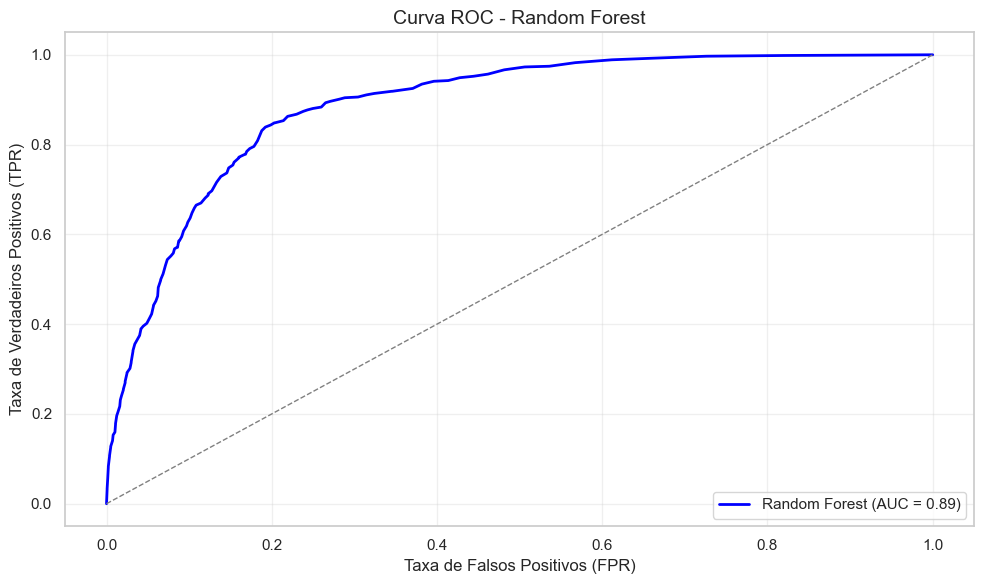

In [111]:
# Obtendo as probabilidades de previsão para o conjunto de teste
y_prob_rf = modelo_rf_final.predict_proba(X_teste)[:, 1]

# Calculando a Curva ROC
fpr, tpr, _ = roc_curve(y_teste, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Gerando o gráfico da Curva ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('Curva ROC - Random Forest', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# Salvando o gráfico
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# Interpretação do Modelo

## Importância das Variáveis

In [108]:
# Importância das variáveis do modelo Random Forest
importancia_variaveis = modelo_rf_final.feature_importances_

# Criando um DataFrame para exibir as variáveis e suas importâncias
importancia_df = pd.DataFrame({
    "Variável": X_treino.columns,
    "Importância": importancia_variaveis
}).sort_values(by="Importância", ascending=False)

# Exibindo as variáveis mais importantes
importancia_df.reset_index(drop=True, inplace=True)
importancia_df.head(10)

,Variável,Importância
0,CREDIT_SCORE,0.175116
1,ANNUAL_MILEAGE,0.101938
2,VEHICLE_OWNERSHIP,0.089794
3,SPEEDING_VIOLATIONS_BOXCOX,0.085284
4,PAST_ACCIDENTS_BOXCOX,0.067620
5,VEHICLE_YEAR_before 2015,0.056828
6,POSTAL_CODE,0.051905
7,DRIVING_EXPERIENCE_10-19y,0.046975
8,INCOME_upper class,0.035686
9,GENDER_male,0.035059


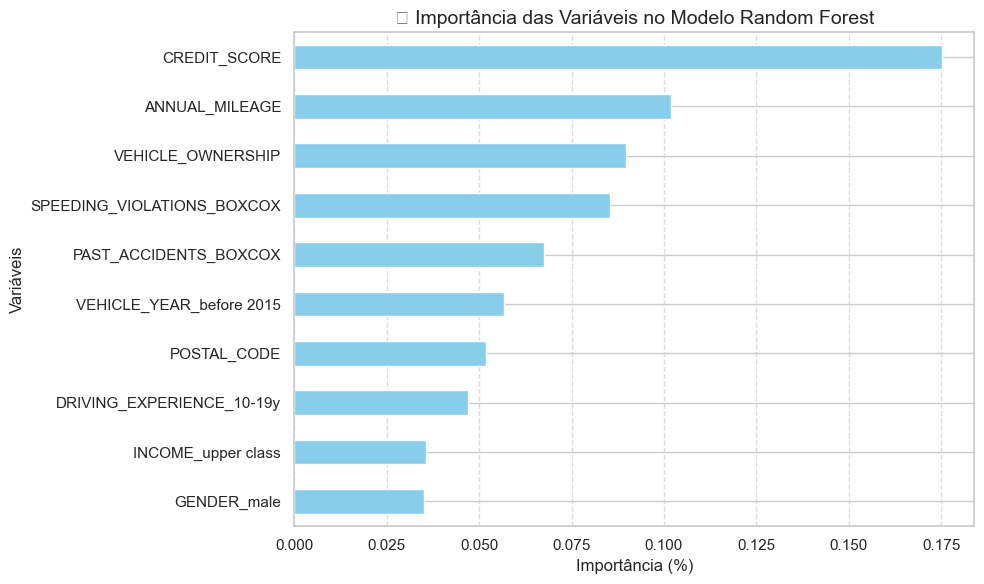

In [112]:
# Importância das variáveis no modelo Random Forest
importancia_df.set_index('Variável', inplace=True)

# Gerando o gráfico de barras
plt.figure(figsize=(10, 6))
importancia_df['Importância'].head(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('🔑 Importância das Variáveis no Modelo Random Forest', fontsize=14)
plt.xlabel('Importância (%)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salvando o gráfico
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Interpretação Geral:
O modelo final evidencia que fatores financeiros, comportamentais e do veículo desempenham papéis cruciais na previsão de sinistros. Variáveis como **CREDIT_SCORE** e **ANNUAL_MILEAGE** destacam a relevância de informações financeiras e comportamentais, enquanto características do veículo e localização também fornecem insights importantes.